In [14]:
from tacoloader import TacoDataLoader
from torch.utils import data
import torchvision.transforms as transforms
from matplotlib.patches import Polygon, Rectangle
from matplotlib.collections import PatchCollection
import matplotlib.pyplot as plt
import numpy as np
import colorsys

In [15]:
size = 512
batch_size = 8
dataset_path = '/dtu/datasets1/02514/data_wastedetection/'
transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])


# dataset training
trainset = TacoDataLoader(data_path=dataset_path, transform=transform, size=size, train=True)
# dataset validation
validationset = TacoDataLoader(data_path=dataset_path, transform=transform, size=size, validation=True)
# dataset test
testset = TacoDataLoader(data_path=dataset_path, size=size, transform=transform)

# dataloader training
train_loader = data.DataLoader(dataset=trainset,
                                batch_size=batch_size,
                                collate_fn=trainset.collate_fn,
                                shuffle=False)
# dataloader validation
validation_loader = data.DataLoader(dataset=validationset,
                                   batch_size=batch_size,
                                   collate_fn=validationset.collate_fn,
                                   shuffle=False)

# dataloader test
test_loader = data.DataLoader(dataset=testset,
                                   batch_size=batch_size,
                                    collate_fn=testset.collate_fn,
                                   shuffle=False)

x, yb, yl = next(iter(test_loader))

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


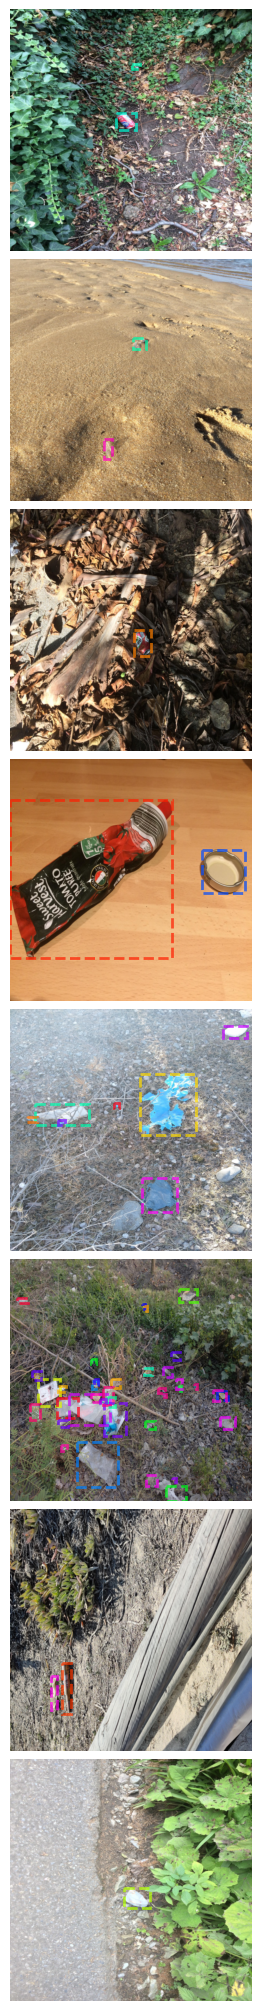

In [17]:
plt.rcParams['figure.figsize'] = [20, 20]

images, bboxes, labels = next(iter(train_loader))
# Show image
fig, ax = plt.subplots(batch_size, layout="compressed")


for i in range(batch_size):
    ax[i].imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))
    ax[i].axis('off')
    
    for bbox in bboxes[i]:
        [x, y, w, h] = bbox
        color = colorsys.hsv_to_rgb(np.random.random(),1,1)

        rect = Rectangle((x,y),w,h,linewidth=2,edgecolor=color,
                             facecolor='none', alpha=0.7, linestyle = '--')
        ax[i].add_patch(rect)
plt.show()